# Problem 4 — Statement 3
## Theo dõi tiến trình và xu hướng đóng góp doanh số của từng nhân viên qua chuỗi thời gian, đánh giá mức độ ổn định

**Đề bài:** *Theo dõi tiến trình và xu hướng đóng góp doanh số của từng nhân viên qua chuỗi thời gian nhằm đánh giá mức độ ổn định trong công việc.*

**Nguồn dữ liệu (silver, đã chuẩn hóa 3NF):**
- `ORDER` (order_id PK; FK: customer_id, zip, sales_employee_id; order_date, order_status, device_type, order_source)
- `ORDER_ITEMS` (order_id + product_id PK; quantity, unit_price, discount_amount)

**Framework áp dụng:** Measure → Metric → KPI
| Bước | Nội dung |
|---|---|
| Measure | `quantity`, `unit_price`, `discount_amount` (ORDER_ITEMS); `order_id`, `order_date`, `order_status`, `sales_employee_id` (ORDER) |
| Metric | Doanh số theo (nhân viên, tháng); số hóa đơn theo (nhân viên, tháng); tăng trưởng MoM |
| KPI | Độ biến động (Coefficient of Variation), Xu hướng (trend slope), Phân loại mức độ ổn định |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (11, 5)


## 1. Load dữ liệu (silver layer)

In [2]:
ORDER_PATH = "../../silver_data/ORDER.csv"
ORDER_ITEMS_PATH = "../../silver_data/ORDER_ITEMS.csv"

df_order = pd.read_csv(ORDER_PATH, parse_dates=["order_date"])
df_items = pd.read_csv(ORDER_ITEMS_PATH)

print("ORDER:", df_order.shape)
print("ORDER_ITEMS:", df_items.shape)
print("Khoảng thời gian:", df_order["order_date"].min(), "->", df_order["order_date"].max())
print("Số nhân viên:", df_order["sales_employee_id"].nunique())


ORDER: (646945, 8)
ORDER_ITEMS: (714653, 5)
Khoảng thời gian: 2012-07-04 00:00:00 -> 2022-12-31 00:00:00
Số nhân viên: 200


## 2. Khám phá sơ bộ dữ liệu

In [3]:
display(df_order.head())
display(df_items.head())

print(df_order["order_status"].value_counts(dropna=False))


,order_id,order_date,customer_id,zip,order_status,device_type,order_source,sales_employee_id
0,1,2012-07-04,58578,1109,delivered,desktop,paid_search,EMP0103
1,2,2012-07-04,58621,1330,returned,mobile,paid_search,EMP0180
2,3,2012-07-04,58811,1473,delivered,desktop,direct,EMP0093
3,4,2012-07-04,59453,2360,delivered,desktop,referral,EMP0015
4,6,2012-07-06,57821,2886,delivered,mobile,email_campaign,EMP0107


,order_id,product_id,quantity,unit_price,discount_amount
0,1,2400,7,"1,138.22",0.00
1,2,609,7,"10,166.25",0.00
2,3,396,3,"11,220.33",0.00
3,4,635,5,"10,639.25",0.00
4,6,1935,1,"1,597.84",0.00


delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: order_status, dtype: int64


## 3. Xác định Measure

| Bảng | Measure | Ý nghĩa |
|---|---|---|
| ORDER | `sales_employee_id` | Chiều phân tích — nhân viên bán hàng |
| ORDER | `order_date` | Chiều phân tích — thời gian (sẽ quy về tháng) |
| ORDER | `order_status` | Lọc đơn hàng xử lý thành công |
| ORDER | `order_id` | Định danh hóa đơn |
| ORDER_ITEMS | `quantity`, `unit_price`, `discount_amount` | Tính doanh thu từng dòng hàng |

Measure dẫn xuất: `doanh_thu_dong = quantity * unit_price - discount_amount`.


In [4]:
df_items["doanh_thu_dong"] = (
    df_items["quantity"] * df_items["unit_price"] - df_items["discount_amount"]
)


## 4. Lọc hóa đơn "xử lý thành công"

Theo dữ liệu thực tế, `order_status` có các giá trị: `delivered`, `cancelled`, `returned`,
`shipped`, `paid`, `created`. Ở đây coi **`delivered`** là trạng thái xử lý thành công
(cần đối chiếu lại với nghiệp vụ thực tế của nhóm nếu định nghĩa khác).


In [5]:
SUCCESSFUL_STATUSES = ["delivered"]

df_order_success = df_order[df_order["order_status"].isin(SUCCESSFUL_STATUSES)].copy()
df_order_success["order_month"] = df_order_success["order_date"].dt.to_period("M").dt.to_timestamp()

print(f"Số đơn hàng thành công: {len(df_order_success):,} / {len(df_order):,}")


Số đơn hàng thành công: 516,716 / 646,945


## 5. Xây dựng Metric

Nối `ORDER_ITEMS` với các đơn hàng thành công, sau đó tổng hợp doanh số và số hóa đơn
theo cặp (`sales_employee_id`, `order_month`) — đây là chuỗi thời gian cho từng nhân viên.


In [6]:
df_merged = df_items.merge(
    df_order_success[["order_id", "sales_employee_id", "order_month"]],
    on="order_id",
    how="inner",
)

monthly_metric = (
    df_merged.groupby(["sales_employee_id", "order_month"])
    .agg(
        doanh_so_thang=("doanh_thu_dong", "sum"),
        so_hoa_don_thang=("order_id", "nunique"),
    )
    .reset_index()
    .sort_values(["sales_employee_id", "order_month"])
)

monthly_metric.head(10)


,sales_employee_id,order_month,doanh_so_thang,so_hoa_don_thang
0,EMP0001,2012-07-01,"572,821.50",19
1,EMP0001,2012-08-01,"490,202.99",19
2,EMP0001,2012-09-01,"326,309.03",19
3,EMP0001,2012-10-01,"295,236.14",19
4,EMP0001,2012-11-01,"447,654.21",18
5,EMP0001,2012-12-01,"325,866.92",24
6,EMP0001,2013-01-01,"566,364.66",18
7,EMP0001,2013-02-01,"381,735.19",13
8,EMP0001,2013-03-01,"566,303.73",24
9,EMP0001,2013-04-01,"561,604.73",31


In [7]:
# Tăng trưởng doanh số theo tháng (Month-over-Month) cho từng nhân viên
monthly_metric["doanh_so_thang_truoc"] = (
    monthly_metric.groupby("sales_employee_id")["doanh_so_thang"].shift(1)
)
monthly_metric["tang_truong_mom_%"] = (
    (monthly_metric["doanh_so_thang"] - monthly_metric["doanh_so_thang_truoc"])
    / monthly_metric["doanh_so_thang_truoc"] * 100
)

monthly_metric.head(10)


,sales_employee_id,order_month,doanh_so_thang,so_hoa_don_thang,doanh_so_thang_truoc,tang_truong_mom_%
0,EMP0001,2012-07-01,"572,821.50",19,nan,nan
1,EMP0001,2012-08-01,"490,202.99",19,"572,821.50",-14.42
2,EMP0001,2012-09-01,"326,309.03",19,"490,202.99",-33.43
3,EMP0001,2012-10-01,"295,236.14",19,"326,309.03",-9.52
4,EMP0001,2012-11-01,"447,654.21",18,"295,236.14",51.63
5,EMP0001,2012-12-01,"325,866.92",24,"447,654.21",-27.21
6,EMP0001,2013-01-01,"566,364.66",18,"325,866.92",73.80
7,EMP0001,2013-02-01,"381,735.19",13,"566,364.66",-32.60
8,EMP0001,2013-03-01,"566,303.73",24,"381,735.19",48.35
9,EMP0001,2013-04-01,"561,604.73",31,"566,303.73",-0.83


## 6. Xây dựng KPI đánh giá mức độ ổn định

- **Doanh số trung bình/tháng** (`doanh_so_tb_thang`) — quy mô đóng góp trung bình.
- **Độ lệch chuẩn doanh số theo tháng** (`std_doanh_so`) — mức dao động tuyệt đối.
- **Hệ số biến động — CV** (`cv_doanh_so = std/mean`) — mức dao động tương đối, dùng để so sánh công bằng
  giữa các nhân viên có quy mô doanh số khác nhau.
- **Xu hướng (trend slope)** (`xu_huong_thang`) — hệ số góc của đường hồi quy tuyến tính doanh số theo tháng
  (dùng `numpy.polyfit`); dương = đang tăng, âm = đang giảm, gần 0 = đi ngang.
- **Xu hướng chuẩn hóa (%/tháng)** — `xu_huong_thang / doanh_so_tb_thang * 100`, để so sánh tốc độ tăng/giảm
  tương đối giữa các nhân viên.
- **Phân loại mức độ ổn định** — kết hợp CV và xu hướng chuẩn hóa thành 4 nhóm:
  - *Ổn định*: CV thấp, xu hướng ở mức trung bình (không thuộc nhóm tốt/xấu rõ rệt)
  - *Tăng trưởng tương đối*: xu hướng thuộc nhóm 25% tốt nhất (ít suy giảm nhất/tăng nhiều nhất)
  - *Suy giảm rõ rệt*: xu hướng thuộc nhóm 25% kém nhất (suy giảm nhiều nhất)
  - *Biến động mạnh*: CV thuộc nhóm cao, không nằm trong 2 nhóm xu hướng cực trị ở trên

**Lưu ý quan trọng:** khi kiểm tra phân phối thực tế trên dữ liệu này, toàn bộ 200 nhân viên
đều có xu hướng **âm** (khoảng −0.73%/tháng đến −0.30%/tháng, trung vị ≈ −0.53%/tháng — tức
doanh số toàn công ty giảm dần khá đồng đều theo thời gian). Vì vậy **không nên dùng ngưỡng
tuyệt đối cố định quanh 0** (sẽ khiến không nhân viên nào rơi vào nhóm "Tăng trưởng"/"Suy giảm").
Thay vào đó, ngưỡng được tính **tương đối theo phân vị (percentile) của chính tập dữ liệu**:
`TREND_HIGH`/`TREND_LOW` = phân vị 75/25 của xu hướng, `CV_THRESHOLD` = trung vị CV — nghĩa là
phân loại theo **vị trí tương đối của từng nhân viên so với mặt bằng chung**, thay vì so với một
mốc tuyệt đối không phản ánh đúng bối cảnh dữ liệu.


In [8]:
def calc_trend_slope(group):
    """Hệ số góc hồi quy tuyến tính: doanh_so_thang ~ thứ tự tháng."""
    g = group.sort_values("order_month")
    x = np.arange(len(g))
    y = g["doanh_so_thang"].values
    if len(g) < 2:
        return np.nan
    slope, _ = np.polyfit(x, y, 1)
    return slope

stability = (
    monthly_metric.groupby("sales_employee_id")["doanh_so_thang"]
    .agg(so_thang_hoat_dong="count", doanh_so_tb_thang="mean", std_doanh_so="std")
    .reset_index()
)
stability["cv_doanh_so"] = stability["std_doanh_so"] / stability["doanh_so_tb_thang"]

# Tính xu hướng: chỉ lấy 2 cột cần thiết trước khi apply để tương thích mọi phiên bản pandas
# (không dùng include_groups vì tham số này chỉ có từ pandas >= 2.2)
trend = (
    monthly_metric.groupby("sales_employee_id")[["order_month", "doanh_so_thang"]]
    .apply(calc_trend_slope)
    .rename("xu_huong_thang")
    .reset_index()
)

stability = stability.merge(trend, on="sales_employee_id")
stability["xu_huong_%_thang"] = stability["xu_huong_thang"] / stability["doanh_so_tb_thang"] * 100

stability.head(10)


,sales_employee_id,so_thang_hoat_dong,doanh_so_tb_thang,std_doanh_so,cv_doanh_so,xu_huong_thang,xu_huong_%_thang
0,EMP0001,126,"496,310.83","267,170.03",0.54,"-2,545.94",-0.51
1,EMP0002,126,"515,609.03","261,888.06",0.51,"-2,523.41",-0.49
2,EMP0003,126,"495,508.67","278,194.47",0.56,"-2,557.75",-0.52
3,EMP0004,126,"500,475.23","277,197.36",0.55,"-2,340.82",-0.47
4,EMP0005,126,"495,270.92","273,637.19",0.55,"-2,213.64",-0.45
5,EMP0006,126,"510,142.82","258,911.38",0.51,"-2,449.14",-0.48
6,EMP0007,126,"502,372.29","299,392.82",0.60,"-2,650.52",-0.53
7,EMP0008,126,"500,437.12","274,589.81",0.55,"-2,032.96",-0.41
8,EMP0009,126,"499,786.43","282,905.31",0.57,"-2,647.60",-0.53
9,EMP0010,126,"503,908.47","263,420.63",0.52,"-2,799.84",-0.56


In [9]:
# Ngưỡng phân loại — TÍNH THEO PHÂN VỊ CỦA CHÍNH TẬP DỮ LIỆU (không neo cứng ở 0).
# Lý do: kiểm tra phân phối thực tế cho thấy TOÀN BỘ nhân viên đều có xu hướng âm
# (dao động hẹp quanh mức trung vị ~-0.53%/tháng) — dùng ngưỡng tuyệt đối quanh 0 sẽ
# khiến không nhân viên nào rơi vào nhóm "Tăng trưởng"/"Suy giảm". Do đó dùng phân vị
# 25/75 để phân loại TƯƠNG ĐỐI giữa các nhân viên với nhau.
CV_THRESHOLD = stability["cv_doanh_so"].median()
TREND_HIGH = stability["xu_huong_%_thang"].quantile(0.75)  # nhóm 25% ít suy giảm nhất
TREND_LOW = stability["xu_huong_%_thang"].quantile(0.25)   # nhóm 25% suy giảm nhiều nhất

print(f"CV_THRESHOLD (trung vị)   = {CV_THRESHOLD:.4f}")
print(f"TREND_HIGH (phân vị 75%)  = {TREND_HIGH:.4f} %/tháng")
print(f"TREND_LOW  (phân vị 25%)  = {TREND_LOW:.4f} %/tháng")

def classify_stability(row):
    if row["xu_huong_%_thang"] >= TREND_HIGH:
        return "Tăng trưởng tương đối"
    if row["xu_huong_%_thang"] <= TREND_LOW:
        return "Suy giảm rõ rệt"
    if row["cv_doanh_so"] <= CV_THRESHOLD:
        return "Ổn định"
    return "Biến động mạnh"

stability["phan_loai_on_dinh"] = stability.apply(classify_stability, axis=1)
stability = stability.sort_values("doanh_so_tb_thang", ascending=False)

stability.head(10)


CV_THRESHOLD (trung vị)   = 0.5487
TREND_HIGH (phân vị 75%)  = -0.4889 %/tháng
TREND_LOW  (phân vị 25%)  = -0.5831 %/tháng


,sales_employee_id,so_thang_hoat_dong,doanh_so_tb_thang,std_doanh_so,cv_doanh_so,xu_huong_thang,xu_huong_%_thang,phan_loai_on_dinh
142,EMP0143,126,"535,293.98","302,970.98",0.57,"-2,946.77",-0.55,Biến động mạnh
162,EMP0163,126,"531,644.24","283,110.09",0.53,"-2,249.96",-0.42,Tăng trưởng tương đối
139,EMP0140,126,"530,445.03","300,097.81",0.57,"-2,856.53",-0.54,Biến động mạnh
57,EMP0058,126,"530,172.12","304,934.18",0.58,"-3,474.83",-0.66,Suy giảm rõ rệt
130,EMP0131,126,"529,495.43","306,547.64",0.58,"-2,544.49",-0.48,Tăng trưởng tương đối
161,EMP0162,126,"528,480.41","291,886.48",0.55,"-2,671.78",-0.51,Biến động mạnh
132,EMP0133,126,"528,179.91","295,410.02",0.56,"-3,235.44",-0.61,Suy giảm rõ rệt
52,EMP0053,126,"527,907.93","311,202.29",0.59,"-2,419.10",-0.46,Tăng trưởng tương đối
168,EMP0169,126,"527,646.47","267,152.29",0.51,"-2,548.53",-0.48,Tăng trưởng tương đối
155,EMP0156,126,"527,031.72","285,813.13",0.54,"-2,932.06",-0.56,Ổn định


In [10]:
print(stability["phan_loai_on_dinh"].value_counts())


Biến động mạnh           51
Tăng trưởng tương đối    50
Suy giảm rõ rệt          50
Ổn định                  49
Name: phan_loai_on_dinh, dtype: int64


## 7. Trực quan hóa

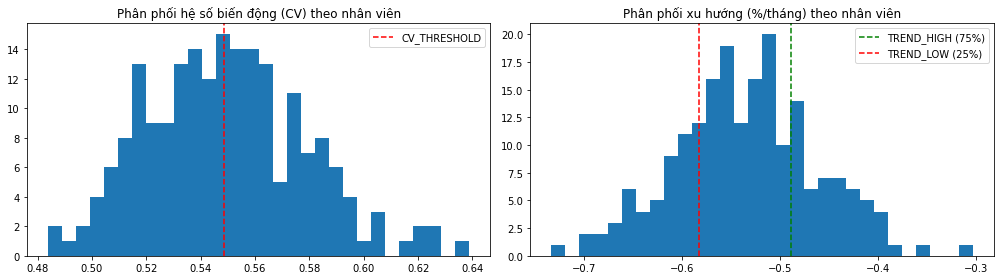

In [11]:
# Phân phối CV và xu hướng để kiểm tra lại ngưỡng phân loại ở bước 6
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(stability["cv_doanh_so"].dropna(), bins=30)
axes[0].axvline(CV_THRESHOLD, color="red", linestyle="--", label="CV_THRESHOLD")
axes[0].set_title("Phân phối hệ số biến động (CV) theo nhân viên")
axes[0].legend()

axes[1].hist(stability["xu_huong_%_thang"].dropna(), bins=30)
axes[1].axvline(TREND_HIGH, color="green", linestyle="--", label="TREND_HIGH (75%)")
axes[1].axvline(TREND_LOW, color="red", linestyle="--", label="TREND_LOW (25%)")
axes[1].set_title("Phân phối xu hướng (%/tháng) theo nhân viên")
axes[1].legend()

plt.tight_layout()
plt.show()


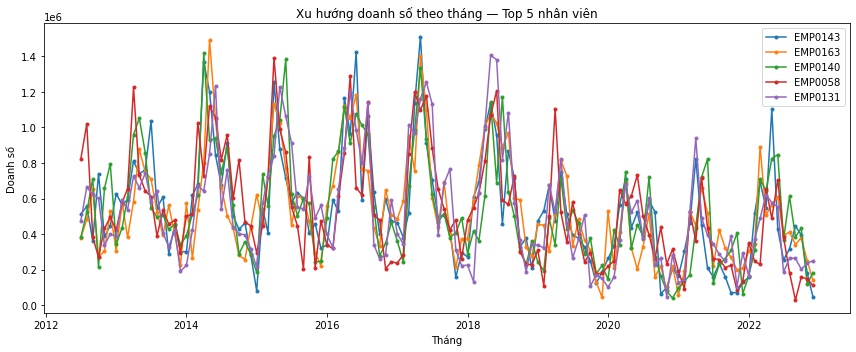

In [12]:
# Chuỗi thời gian doanh số của Top 5 nhân viên theo doanh số trung bình/tháng
top5 = stability.sort_values("doanh_so_tb_thang", ascending=False).head(5)["sales_employee_id"]

fig, ax = plt.subplots(figsize=(12, 5))
for emp_id in top5:
    series = monthly_metric[monthly_metric["sales_employee_id"] == emp_id]
    ax.plot(series["order_month"], series["doanh_so_thang"], marker="o", markersize=3, label=emp_id)

ax.set_title("Xu hướng doanh số theo tháng — Top 5 nhân viên")
ax.set_xlabel("Tháng")
ax.set_ylabel("Doanh số")
ax.legend()
plt.tight_layout()
plt.show()


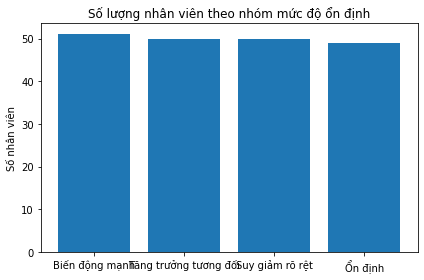

In [13]:
# Số lượng nhân viên theo từng nhóm phân loại ổn định
counts = stability["phan_loai_on_dinh"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values)
ax.set_title("Số lượng nhân viên theo nhóm mức độ ổn định")
ax.set_ylabel("Số nhân viên")
plt.tight_layout()
plt.show()


## 8. Xuất kết quả

In [15]:
OUTPUT_MONTHLY = "../output/problem4_statement3_monthly_by_employee.csv"
OUTPUT_STABILITY = "../output/problem4_statement3_stability_kpi.csv"

df_order = pd.read_csv(ORDER_PATH, parse_dates=["order_date"])
df_items = pd.read_csv(ORDER_ITEMS_PATH)

monthly_metric.to_csv(OUTPUT_MONTHLY, index=False)
stability.to_csv(OUTPUT_STABILITY, index=False)

print(f"Đã lưu chuỗi thời gian theo tháng vào: {OUTPUT_MONTHLY}")
print(f"Đã lưu bảng KPI ổn định vào: {OUTPUT_STABILITY}")


Đã lưu chuỗi thời gian theo tháng vào: ../output/problem4_statement3_monthly_by_employee.csv
Đã lưu bảng KPI ổn định vào: ../output/problem4_statement3_stability_kpi.csv
